# 02 — Analysis & Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('data/processed/plots', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df1_clean  = pd.read_csv('data/processed/clinical_clean.csv')
df2_clean = pd.read_csv('data/processed/biospecimen_clean.csv')

print('Clinical shape    :', df1_clean.shape)
print('Biospecimen shape :', df2_clean.shape)

Clinical shape    : (608, 11)
Biospecimen shape : (608, 9)


---
## Clinical Dataset — Audit & Plots

In [2]:
print('Rows :', df1_clean.shape[0])
print('Columns :', df1_clean.shape[1])
print('Unique patients :', df1_clean['case_id'].nunique())
print('\nMissingness (%):')
print(df1_clean.isna().mean().mul(100).sort_values(ascending=False).round(1))
print('\nBasic stats:')
print(df1_clean.describe(include='all').T)

Rows : 608
Columns : 11
Unique patients : 608

Missingness (%):
days_to_death    42.8
primary_site      0.0
case_id           0.0
disease_type      0.0
sex_at_birth      0.0
days_to_birth     0.0
age_at_index      0.0
race              0.0
vital_status      0.0
figo_stage        0.0
tumor_grade       0.0
dtype: float64

Basic stats:
               count unique                                    top freq  \
case_id          608    608   005a6517-2e5a-4ea3-ab36-531522723607    1   
primary_site     608      2                                  Ovary  601   
disease_type     608      1  Cystic, Mucinous and Serous Neoplasms  608   
sex_at_birth     608      1                                 female  608   
age_at_index   608.0    NaN                                    NaN  NaN   
days_to_birth  608.0    NaN                                    NaN  NaN   
race             608      6                                  white  498   
vital_status     608      3                                   Dea

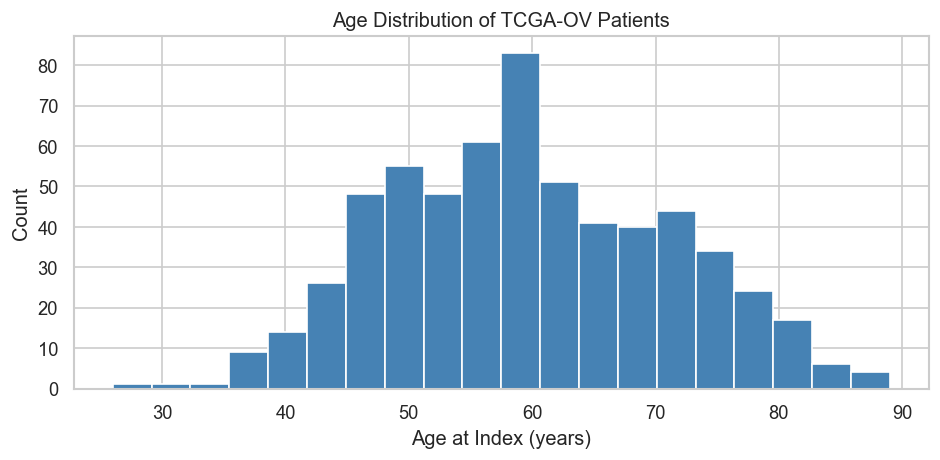

In [3]:
plt.figure(figsize=(8, 4))
df1_clean['age_at_index'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of TCGA-OV Patients')
plt.xlabel('Age at Index (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_age_distribution.png', dpi=150)
plt.show()

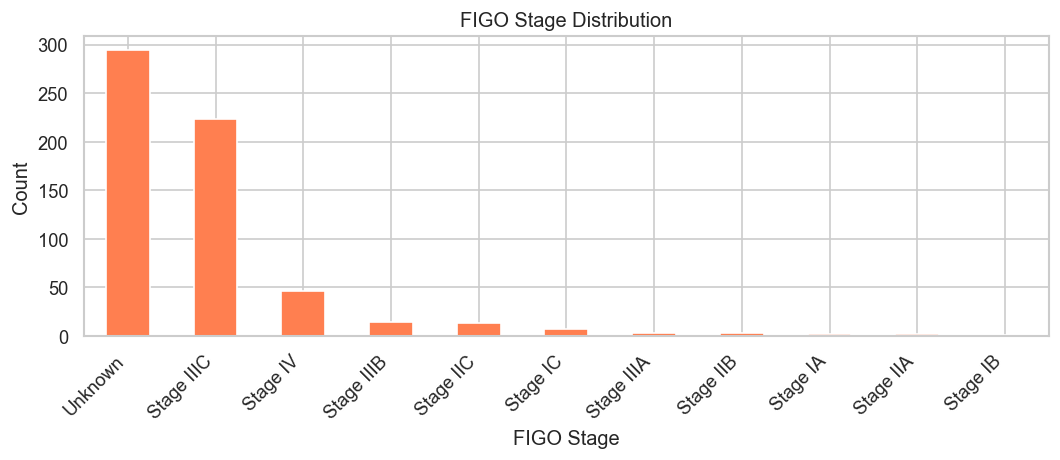

In [4]:
plt.figure(figsize=(9, 4))
df1_clean['figo_stage'].value_counts().plot(kind='bar', color='coral', edgecolor='white')
plt.title('FIGO Stage Distribution')
plt.xlabel('FIGO Stage')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_figo_stage.png', dpi=150)
plt.show()

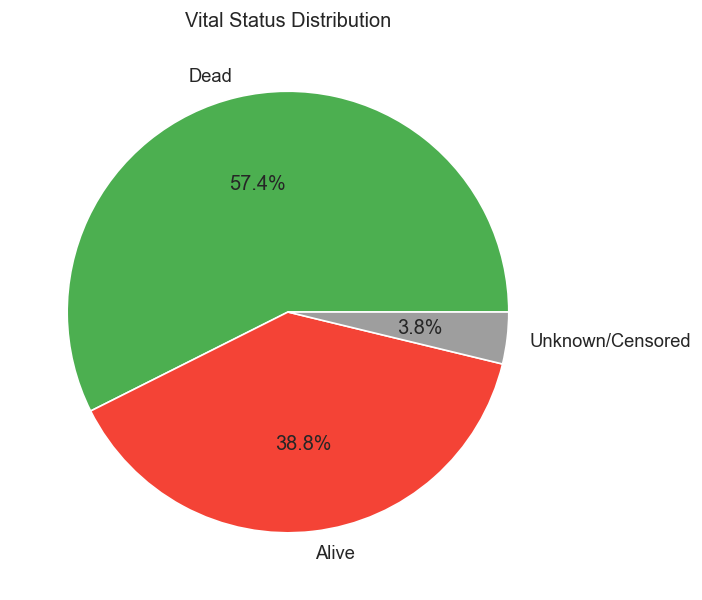

In [5]:
plt.figure(figsize=(6, 6))
df1_clean['vital_status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#4CAF50','#F44336','#9E9E9E','#FFB300']
)
plt.title('Vital Status Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_vital_status.png', dpi=150)
plt.show()

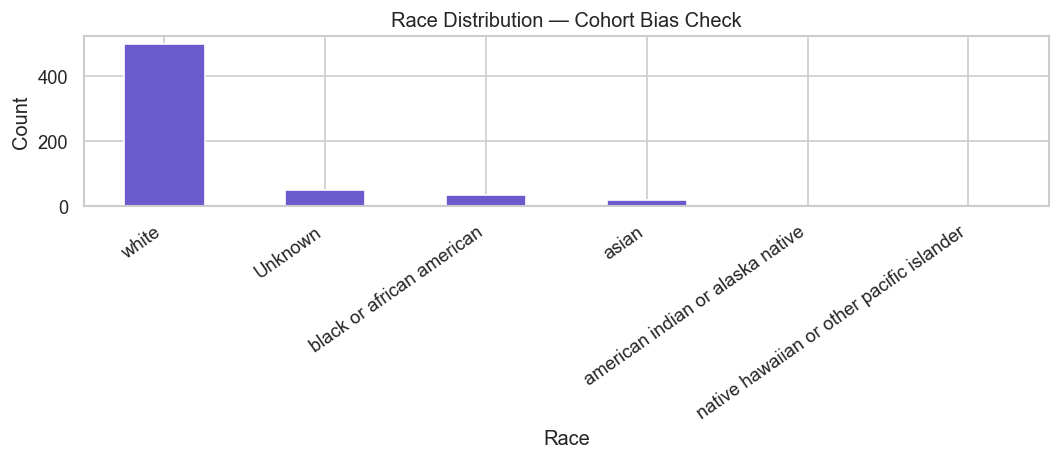

In [6]:
plt.figure(figsize=(9, 4))
df1_clean['race'].value_counts().plot(kind='bar', color='slateblue', edgecolor='white')
plt.title('Race Distribution — Cohort Bias Check')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_race_distribution.png', dpi=150)
plt.show()


## Biospecimen Dataset 

In [7]:

print('Rows            :', df2_clean.shape[0])
print('Columns         :', df2_clean.shape[1])
print('Unique patients :', df2_clean['case_id'].nunique())
print('\nMissingness (%):')
print(df2_clean.isna().mean().mul(100).sort_values(ascending=False).round(1))
print('\nBasic stats:')
print(df2_clean.describe(include='all').T)

Rows            : 608
Columns         : 9
Unique patients : 608

Missingness (%):
analyte_type        47.0
case_id              0.0
submitter_id         0.0
sample_id            0.0
tumor_descriptor     0.0
sample_type          0.0
tissue_type          0.0
weight               0.0
is_ffpe              0.0
dtype: float64

Basic stats:
                  count unique                                   top freq  \
case_id             608    608  005a6517-2e5a-4ea3-ab36-531522723607    1   
submitter_id        608    608                          TCGA-61-1740    1   
tumor_descriptor    608      3                               Primary  325   
sample_id           608    608  ac9c5b5e-8e14-4a76-a68d-78a8349c40f7    1   
sample_type         608      4                         Primary Tumor  325   
tissue_type         608      2                                 Tumor  331   
weight            608.0    NaN                                   NaN  NaN   
is_ffpe             608      1                  

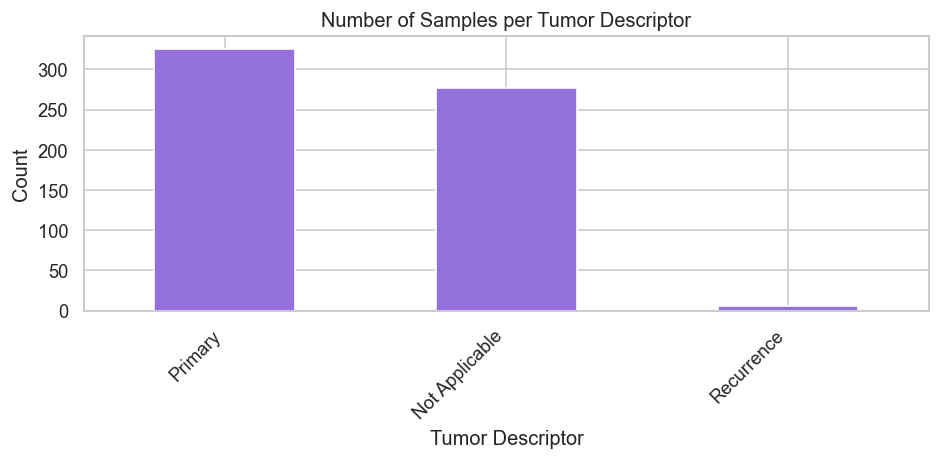

In [8]:
plt.figure(figsize=(8, 4))
df2_clean['tumor_descriptor'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Number of Samples per Tumor Descriptor')
plt.xlabel('Tumor Descriptor')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_tumor_descriptor.png', dpi=150)
plt.show()

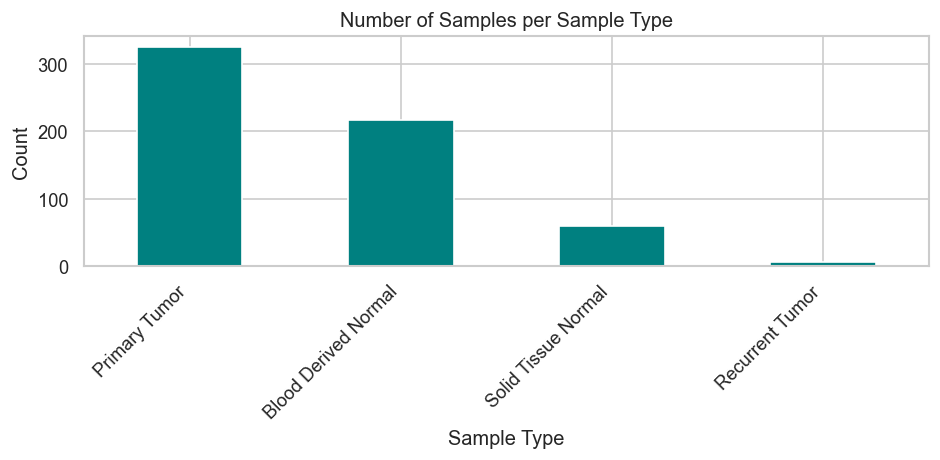

In [9]:
plt.figure(figsize=(8, 4))
df2_clean['sample_type'].value_counts().plot(kind='bar', color='teal', edgecolor='white')
plt.title('Number of Samples per Sample Type')
plt.xlabel('Sample Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_sample_type.png', dpi=150)
plt.show()

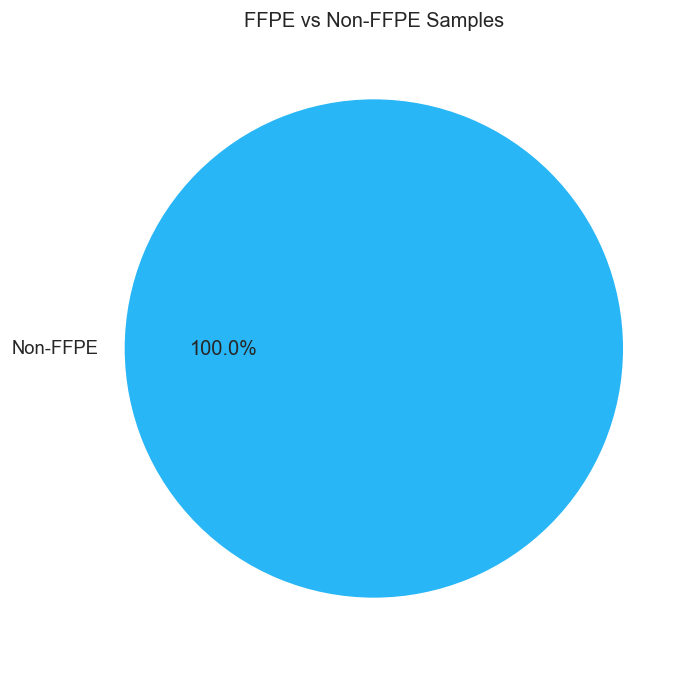

In [10]:
plt.figure(figsize=(6, 6))
df2_clean['is_ffpe'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    labels=['Non-FFPE','FFPE'],
    colors=['#29B6F6','#EF5350']
)
plt.title('FFPE vs Non-FFPE Samples')
plt.ylabel('')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_ffpe.png', dpi=150)
plt.show()

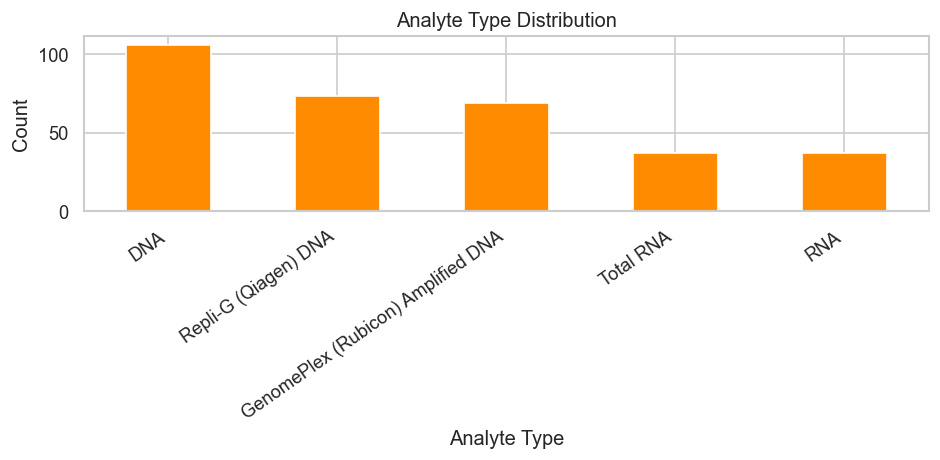


All plots saved to data/processed/plots/


In [11]:
plt.figure(figsize=(8, 4))
df2_clean['analyte_type'].value_counts().plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Analyte Type Distribution')
plt.xlabel('Analyte Type')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_analyte_type.png', dpi=150)
plt.show()

print('\nAll plots saved to data/processed/plots/')